## Outlier

- What is an outlier?
    - Any value that does not belong to the data
        - too large
        - too small
        - too far from mean

In [49]:
import numpy as np
import pandas as pd

data = {
    'ID': [x + 100 for x in range(1, 22)],
    'Name': ['Morozov', 'Alice Smith', 'Bob Jones', 'Charlie John', 'David Lee', 'Eve Martinez', 'Frank Wright', 'Grace Lee', 'Hank Brown', 'Ivy Thompson', 'Jack Davis', 'Athalia', 'Amanda', 'Jacquelina', 'Raphael', 'Rosa Linda', 'Rafeeqa', 'Ameena', 'Raisyaa', 'Hayfa', 'Raisyaa'],
    'Email': ['morosechild@mail', 'alicesmith@mail', None, 'charlie@mail', 'davlee@mail', 'evemartin@mail', 'frank@mail', 'ggrace@mail', None, 'ivytom@mail', 'dav_jac@mail', 'athalia@mail', 'aman_da@mail', 'jac_q@mail', 'Ralph_ael@mail', None, 'feeqa_raff@mail', 'meena@mail', 'syaa_raai@mail', 'hayfa@mail', 'syaa_raai@mail'],
    'Product': ['Camera', None, 'Pc', 'Console', 'Keyboard', 'Pc', 'Keyboard', 'Mouse', 'Cd', 'Pc', 'Headphone', 'Keyboard', None, 'Mouse', 'Pc', 'Smartwatch', 'Tablet', 'Pc', None, 'Headphone', None],
    'Quantity': [3, 1, 1, 1, 1, 1, 2, 1, None, 1, 3, None, 1, 1, 2, 1, None, 1, 2, 2, 2],
    'Price': [41010.99, 987.09, 505.65, 30000.00, 187.90, 199.99, None, 57.00, 90.00, 900.89, 503.77, None, 209.00, 244.56, 99.08, 800.00, 1000.00, 676.00, 761.00, 97.00, 761.00],
    'Delivery': [True, True, True, True, False, True, False, True, True, False, True, False, False, False, False, False, True, True, True, True, True],
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '04/01/2023', '2023-01-06', '2023-01-07', '9th Jan 2024', '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17', '2023-01-18', '20/01/2023', '2023-01-20', '20/01/2023']
}

df = pd.DataFrame(data)
df

,ID,Name,Email,Product,Quantity,Price,Delivery,Date
0,101,Morozov,morosechild@mail,Camera,3.0,41010.99,True,2023-01-01
1,102,Alice Smith,alicesmith@mail,NaN,1.0,987.09,True,2023-01-02
2,103,Bob Jones,NaN,Pc,1.0,505.65,True,2023-01-03
3,104,Charlie John,charlie@mail,Console,1.0,30000.00,True,2023-01-04
4,105,David Lee,davlee@mail,Keyboard,1.0,187.90,False,04/01/2023
5,106,Eve Martinez,evemartin@mail,Pc,1.0,199.99,True,2023-01-06
6,107,Frank Wright,frank@mail,Keyboard,2.0,NaN,False,2023-01-07
7,108,Grace Lee,ggrace@mail,Mouse,1.0,57.00,True,9th Jan 2024
8,109,Hank Brown,NaN,Cd,NaN,90.00,True,2023-01-09
9,110,Ivy Thompson,ivytom@mail,Pc,1.0,900.89,False,2023-01-10


In [ ]:
import seaborn as sns

data = pd.Series([18, 20, 20, 20, 23, 25, 30, 30, 25, 30, 35, 40, 68])
data.describe()

count    13.000000
mean     29.538462
std      13.257799
min      18.000000
25%      20.000000
50%      25.000000
75%      30.000000
max      68.000000
dtype: float64

In [35]:
Q = data.quantile([0, 0.25, 0.5, 0.75, 1])
print(Q)

0.00    18.0
0.25    20.0
0.50    25.0
0.75    30.0
1.00    68.0
dtype: float64


In [42]:
Q1 = Q[0.25]
Q3 = Q[0.75]
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

data[(data < lower) | (data > upper)]

5.0 45.0


12    68
dtype: int64

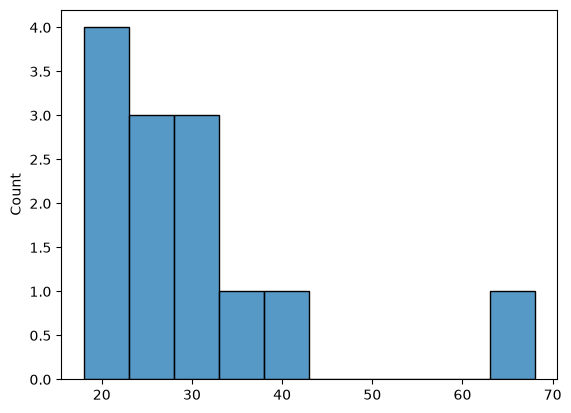

In [38]:
import matplotlib.pyplot as plt
sns.histplot(data, bins= 10)
plt.show()

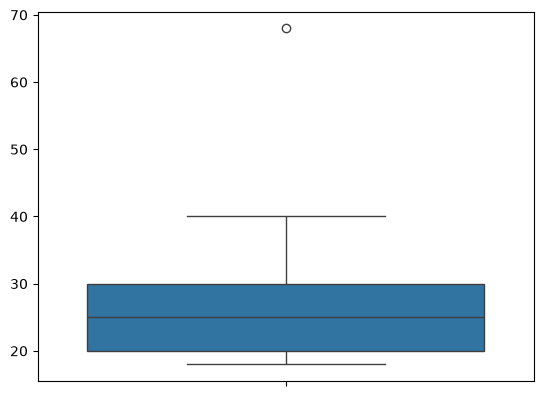

In [39]:
sns.boxplot(data)
plt.show()

In [ ]:
df2 = df.copy()

sns.boxplot(df2)

### IQR method of Outlier Removal

Inter Quartile Range:
- IQR = Q3 - Q1

- to define normal data:
    - we decide what the lower bound and upper bound should be
    - anything beyond is outliers

- lower = Q1 - 1.5 * IQR

- upper = Q3 + 1.5 * IQR

In [ ]:
# Detect and remove outliers from df2.Price


In [ ]:
sns.boxplot(data= df2[['Price', 'Quantity']])

### Date Time - Formats

In [ ]:
df2.Date = pd.to_datetime(df2.Date, format= 'mixed')
df2.Date

In [ ]:
df2.Date.dt.year
df2.Date.dt.day_name()
df2.Date.dt.month_name()

### Types of DTypes in pandas?
- object, int64, float, str, 
- object
    - mixed up
- int64
    - number
- float
    - decimal
- bool
    - True False
- datetime - timedelta
    - date and time
- Category
    - categorical data

In [48]:
movie = {
    'Title': ['Inception', 'The Dark Knight', 'Interstellar', 'The Matrix', 'Pulp Fiction'],
    'Year': [2010, 2008, 2014, 1999, 1994],
    'Box_Office_Billions': [0.829, 1.005, 0.677, 0.463, 0.213],
    'Won_Oscar': [True, True, False, False, True],
    'Released': ['2010-07-16', '2008-07-18', '2014-11-07', '1999-03-31', '1994-10-14'],
    'Genre': ['Sci-Fi', 'Action', 'Sci-Fi', 'Sci-Fi', 'Crime']
}

df_movie = pd.DataFrame(movie)

df_movie.Released = pd.to_datetime(df_movie.Released)
df_movie.Genre = df_movie.Genre.astype('category')

df_movie.dtypes

Title                             str
Year                            int64
Box_Office_Billions           float64
Won_Oscar                        bool
Released               datetime64[us]
Genre                        category
dtype: object